Imports

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor


Matplotlib is building the font cache; this may take a moment.


Load Data

In [2]:
train_path = "../data/processed/train_dropmissing.csv"
test_path = "../data/processed/test_dropmissing.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

id_col = "record_id"
target = "flood_risk_score"

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train missing:", train.isnull().sum().sum())
print("Test missing:", test.isnull().sum().sum())
print("Duplicate train IDs:", train[id_col].duplicated().sum())
print("Duplicate test IDs:", test[id_col].duplicated().sum())
print("Train-only columns:", set(train.columns) - set(test.columns))
print("Test-only columns:", set(test.columns) - set(train.columns))
print("Target valid:", train[target].between(0, 1).all())


Train shape: (15518, 69)
Test shape: (5300, 68)
Train missing: 0
Test missing: 0
Duplicate train IDs: 0
Duplicate test IDs: 0
Train-only columns: {'flood_risk_score'}
Test-only columns: set()
Target valid: True


Apha Pack Feature Engineering


In [3]:
def add_alpha_pack_features(df):
    df = df.copy()
    eps = 1e-5
    
    if "distance_to_river_m_clipped" in df.columns:
        distance = df["distance_to_river_m_clipped"]
    else:
        distance = df["distance_to_river_m"].clip(lower=0)
    
    if "rainfall_7d_mm_clipped" in df.columns:
        rainfall_7d = df["rainfall_7d_mm_clipped"]
    else:
        rainfall_7d = df["rainfall_7d_mm"].clip(lower=0)
    
    inundation = df["inundation_area_sqm"].clip(lower=0)
    
    df["GOLDEN_distance_rainfall_ratio"] = (
        np.log1p(distance) - np.log1p(rainfall_7d + eps)
    )
    
    df["distance_to_river_DIV_inundation_area"] = (
        distance / (inundation + eps)
    )
    
    df["distance_to_river_DIV_rainfall_7d"] = (
        distance / (rainfall_7d + eps)
    )
    
    df["rainfall_7d_MULT_inundation_area"] = (
        rainfall_7d * inundation
    )
    
    new_cols = [
        "GOLDEN_distance_rainfall_ratio",
        "distance_to_river_DIV_inundation_area",
        "distance_to_river_DIV_rainfall_7d",
        "rainfall_7d_MULT_inundation_area"
    ]
    
    for col in new_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())
    
    return df


train_fe = add_alpha_pack_features(train)
test_fe = add_alpha_pack_features(test)

print("After feature engineering:")
print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)
print("Train missing:", train_fe.isnull().sum().sum())
print("Test missing:", test_fe.isnull().sum().sum())

After feature engineering:
Train shape: (15518, 73)
Test shape: (5300, 72)
Train missing: 0
Test missing: 0


Define 35 Alpha Packe Features

In [4]:
alpha_pack_features = [
    "district",
    "distance_to_river_DIV_inundation_area",
    "distance_to_river_DIV_rainfall_7d",
    "GOLDEN_distance_rainfall_ratio",
    "generation_date",
    "reason_not_good_to_live",
    "inundation_area_sqm",
    "infrastructure_score",
    "extreme_weather_index",
    "terrain_roughness_index",
    "road_quality",
    "monthly_rainfall_mm_log1p",
    "landcover",
    "rainfall_7d_MULT_inundation_area",
    "place_name",
    "rainfall_7d_mm",
    "seasonal_index",
    "ndwi_qmap",
    "latitude",
    "longitude",
    "distance_to_river_m",
    "ndwi",
    "water_supply",
    "nearest_evac_km_log1p",
    "elevation_m_yeojohnson",
    "monthly_rainfall_mm",
    "socioeconomic_status_index",
    "population_density_per_km2_log1p",
    "water_presence_flag",
    "nearest_hospital_km_log1p",
    "ndvi_qmap",
    "flood_occurrence_current_event",
    "rainfall_7d_mm_log1p",
    "soil_type",
    "population_density_per_km2"
]

missing_train_features = [col for col in alpha_pack_features if col not in train_fe.columns]
missing_test_features = [col for col in alpha_pack_features if col not in test_fe.columns]

print("Number of Alpha Pack features:", len(alpha_pack_features))
print("Missing train features:", missing_train_features)
print("Missing test features:", missing_test_features)

if missing_train_features or missing_test_features:
    raise ValueError("Some Alpha Pack features are missing. Stop and check columns.")

Number of Alpha Pack features: 35
Missing train features: []
Missing test features: []


Prepare Model Data

In [5]:
X = train_fe[alpha_pack_features].copy()
y = train_fe[target].copy()

X_test = test_fe[alpha_pack_features].copy()
test_ids = test_fe[id_col].copy()

cat_features = [
    col for col in X.columns
    if X[col].dtype == "object" or str(X[col].dtype) == "str"
]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)
print("Missing in X:", X.isnull().sum().sum())
print("Missing in X_test:", X_test.isnull().sum().sum())
print("Feature columns match:", list(X.columns) == list(X_test.columns))
print("Categorical features:", cat_features)

X shape: (15518, 35)
y shape: (15518,)
X_test shape: (5300, 35)
Missing in X: 0
Missing in X_test: 0
Feature columns match: True
Categorical features: ['district', 'generation_date', 'reason_not_good_to_live', 'road_quality', 'landcover', 'place_name', 'water_supply', 'water_presence_flag', 'flood_occurrence_current_event', 'soil_type']


Create Target Bins

In [6]:
target_bins = pd.cut(
    y,
    bins=[-0.001, 0.2, 0.4, 0.6, 0.8, 1.001],
    labels=[0, 1, 2, 3, 4]
)

print("Target bin distribution:")
print(target_bins.value_counts().sort_index())

Target bin distribution:
flood_risk_score
0    1899
1    3455
2    5993
3    2655
4    1516
Name: count, dtype: int64


Cross Validation Training

In [7]:
n_splits = 5
seed = 42

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, target_bins), 1):
    print("\n" + "=" * 70)
    print(f"Fold {fold}")
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=seed + fold,
        verbose=300,
        early_stopping_rounds=200,
        allow_writing_files=False
    )
    
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )
    
    valid_preds = model.predict(X_valid)
    valid_preds = np.clip(valid_preds, 0, 1)
    
    oof_preds[valid_idx] = valid_preds
    
    fold_test_preds = model.predict(X_test)
    test_preds += fold_test_preds / n_splits
    
    rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
    mae = mean_absolute_error(y_valid, valid_preds)
    r2 = r2_score(y_valid, valid_preds)
    
    fold_scores.append({
        "fold": fold,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "best_iteration": model.get_best_iteration()
    })
    
    print("Fold RMSE:", rmse)
    print("Fold MAE :", mae)
    print("Fold R2  :", r2)

oof_preds = np.clip(oof_preds, 0, 1)
test_preds = np.clip(test_preds, 0, 1)

cv_rmse = np.sqrt(mean_squared_error(y, oof_preds))
cv_mae = mean_absolute_error(y, oof_preds)
cv_r2 = r2_score(y, oof_preds)

print("\nOverall CV Results")
print("CV RMSE:", cv_rmse)
print("CV MAE :", cv_mae)
print("CV R2  :", cv_r2)

fold_scores_df = pd.DataFrame(fold_scores)
fold_scores_df


Fold 1
0:	learn: 0.2364969	test: 0.2360924	best: 0.2360924 (0)	total: 71.5ms	remaining: 2m 23s
300:	learn: 0.2255166	test: 0.2317478	best: 0.2317092 (271)	total: 3.37s	remaining: 19s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.2316819405
bestIteration = 351

Shrink model to first 352 iterations.
Fold RMSE: 0.23168194068370526
Fold MAE : 0.17632492961934465
Fold R2  : 0.038713533847676174

Fold 2
0:	learn: 0.2367391	test: 0.2350707	best: 0.2350707 (0)	total: 8.83ms	remaining: 17.7s
300:	learn: 0.2254899	test: 0.2303922	best: 0.2303872 (299)	total: 3.81s	remaining: 21.5s
600:	learn: 0.2174353	test: 0.2303459	best: 0.2302005 (420)	total: 7.62s	remaining: 17.7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.2302004942
bestIteration = 420

Shrink model to first 421 iterations.
Fold RMSE: 0.23020049457971475
Fold MAE : 0.1750286484506056
Fold R2  : 0.042441308901750685

Fold 3
0:	learn: 0.2367448	test: 0.2350777	best: 0.2350777 (0)	total: 10.6m

,fold,rmse,mae,r2,best_iteration
0,1,0.231682,0.176325,0.038714,351
1,2,0.230200,0.175029,0.042441,420
2,3,0.230675,0.176050,0.038614,155
3,4,0.233532,0.177167,0.038389,355
4,5,0.232935,0.178458,0.043007,480


Prediction Distribution

Test prediction distribution:
Min : 0.3678271653498627
Max : 0.6323633148781503
Mean: 0.47911283671415483
Std : 0.044751843087494254


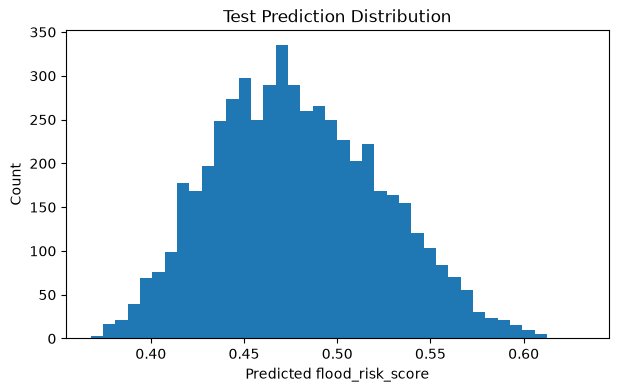

In [8]:
print("Test prediction distribution:")
print("Min :", test_preds.min())
print("Max :", test_preds.max())
print("Mean:", test_preds.mean())
print("Std :", test_preds.std())

plt.figure(figsize=(7, 4))
plt.hist(test_preds, bins=40)
plt.title("Test Prediction Distribution")
plt.xlabel("Predicted flood_risk_score")
plt.ylabel("Count")
plt.show()

Train Final Production Model

In [9]:
final_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=300,
    allow_writing_files=False
)

final_model.fit(
    X,
    y,
    cat_features=cat_features
)

0:	learn: 0.2364213	total: 24.6ms	remaining: 49.2s
300:	learn: 0.2263208	total: 2.67s	remaining: 15.1s
600:	learn: 0.2191634	total: 6.77s	remaining: 15.8s
900:	learn: 0.2134149	total: 11s	remaining: 13.4s
1200:	learn: 0.2077464	total: 15.2s	remaining: 10.1s
1500:	learn: 0.2026417	total: 19.4s	remaining: 6.44s
1800:	learn: 0.1976976	total: 23.7s	remaining: 2.62s
1999:	learn: 0.1945250	total: 26.6s	remaining: 0us


CatBoostRegressor(allow_writing_files=False, depth=6, eval_metric='RMSE', iterations=2000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=300)

Feature Importance

In [10]:
feature_importance = pd.DataFrame({
    "feature": alpha_pack_features,
    "importance": final_model.get_feature_importance()
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,district,4.715236
14,place_name,4.672924
4,generation_date,4.614749
24,elevation_m_yeojohnson,4.452070
29,nearest_hospital_km_log1p,4.186972
8,extreme_weather_index,4.089868
16,seasonal_index,4.070154
9,terrain_roughness_index,4.019527
6,inundation_area_sqm,3.959125
1,distance_to_river_DIV_inundation_area,3.878371


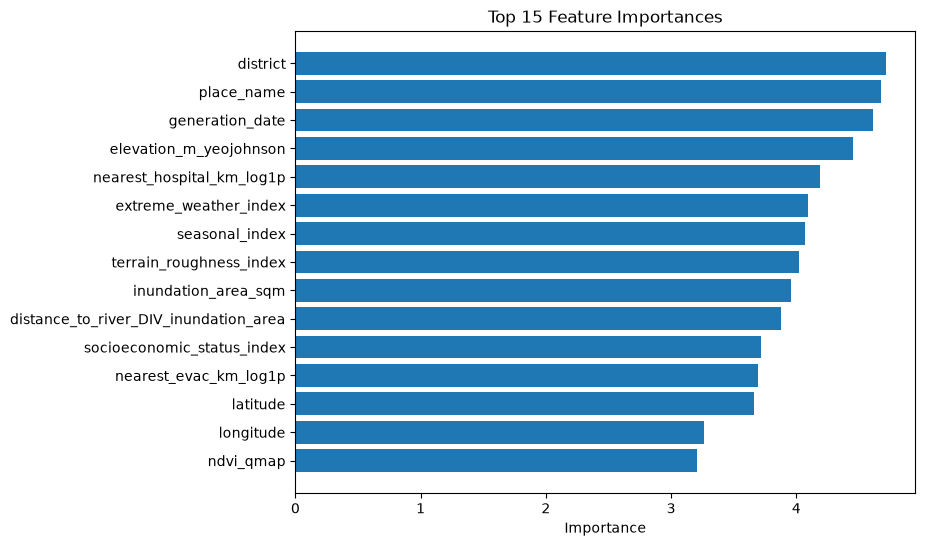

In [11]:
top_n = 15

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance.head(top_n)["feature"][::-1],
    feature_importance.head(top_n)["importance"][::-1]
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [12]:
os.makedirs("../reports", exist_ok=True)
feature_importance.to_csv("../reports/champion_v1_feature_importance.csv", index=False)
fold_scores_df.to_csv("../reports/champion_v1_cv_fold_scores.csv", index=False)

Save Model and Artifacts

In [13]:
os.makedirs("../models/champion_v1", exist_ok=True)

final_model.save_model("../models/champion_v1/catboost_model.cbm")

with open("../models/champion_v1/feature_list.json", "w") as f:
    json.dump(alpha_pack_features, f, indent=4)

with open("../models/champion_v1/categorical_features.json", "w") as f:
    json.dump(cat_features, f, indent=4)

model_metadata = {
    "model_name": "CatBoost Alpha Pack Drop-Missing",
    "model_version": "champion_v1",
    "model_type": "CatBoostRegressor",
    "target": target,
    "id_column": id_col,
    "training_data": "train_dropmissing.csv",
    "test_data": "test_dropmissing.csv",
    "feature_count": len(alpha_pack_features),
    "categorical_feature_count": len(cat_features),
    "validation_method": "Target-binned StratifiedKFold",
    "n_splits": n_splits,
    "random_seed": seed,
    "cv_rmse": float(cv_rmse),
    "cv_mae": float(cv_mae),
    "cv_r2": float(cv_r2),
    "prediction_min": float(test_preds.min()),
    "prediction_max": float(test_preds.max()),
    "prediction_mean": float(test_preds.mean()),
    "prediction_std": float(test_preds.std()),
    "round1_public_score": 0.38176,
    "status": "Champion v1",
    "notes": "Based on Round 1 best setup: CatBoost Alpha Pack with drop-missing train rows."
}

with open("../models/champion_v1/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved model and artifacts successfully.")

Saved model and artifacts successfully.
